# Phase 5 — Backtesting & Evaluation

**This notebook touches the test set for the first time.**

Run every cell top to bottom. This notebook:
1. Loads both trained agents (DQN + PPO) from `models/`
2. Runs deterministic episodes on the test set (2022–2024)
3. Computes Sharpe, drawdown, return, win rate, Calmar, trade frequency
4. Compares both agents against Buy & Hold
5. Generates QuantStats HTML tearsheets
6. Produces a full Plotly trade signal chart

---
## Cell 1 — Imports & path setup

In [3]:
# Cell 1a first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('OK')

OK


In [4]:
# Cell 1b separately — watch which line it stops on
import sys, os
from pathlib import Path

def _find_project_root() -> str:
    """Find the repo root by locating env/trading_env.py."""
    cwd = Path.cwd().resolve()
    for p in (cwd, cwd.parent):
        if (p / 'env' / 'trading_env.py').is_file():
            return str(p)
    raise RuntimeError(f"Could not find project root from cwd={cwd}")

PROJECT_ROOT = _find_project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('importing torch...')
import torch
print(f'torch {torch.__version__} — OK')

print('importing stable-baselines3...')
from stable_baselines3 import DQN, PPO
print('SB3 — OK')

print('importing TradingEnv...')
from env.trading_env import TradingEnv
print('TradingEnv — OK')

importing torch...
torch 2.11.0 — OK
importing stable-baselines3...
SB3 — OK
importing TradingEnv...
TradingEnv — OK


---
## Cell 2 — Load test data

> This is the first time `test.csv` is opened. Do not loop back and retrain after seeing these results.

In [6]:
# Backtest config (keep in sync with training)
TICKER = 'AAPL'
WINDOW_SIZE = 10
MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
REPORT_DIR = os.path.join(PROJECT_ROOT, 'reports')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Load test split (scaled features) + raw OHLCV (real dollar prices)
test_df = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data', 'processed', 'test.csv'),
    index_col=0, parse_dates=True
)
raw_all = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data', 'raw', f'{TICKER}.csv'),
    index_col=0, parse_dates=True
)
if isinstance(raw_all.columns, pd.MultiIndex):
    raw_all.columns = raw_all.columns.get_level_values(0)

test_raw = raw_all.loc[test_df.index]

assert (test_raw['Close'] > 0).all(), 'FAIL: Negative prices in test_raw'
assert len(test_df) == len(test_raw),  'FAIL: Row count mismatch'

print(f'Test period : {test_df.index[0].date()} --> {test_df.index[-1].date()}')
print(f'Test rows   : {len(test_df)}')
print(f'Price range : ${test_raw["Close"].min():.2f} --> ${test_raw["Close"].max():.2f}')
print()
print('[PASS] Test data loaded. Raw prices confirmed positive.')

Test period : 2022-01-03 --> 2024-12-30
Test rows   : 752
Price range : $123.05 --> $257.61

[PASS] Test data loaded. Raw prices confirmed positive.


---
## Cell 3 — Load trained models

In [7]:
dqn_path = os.path.join(MODEL_DIR, f'dqn_{TICKER.lower()}.zip')
ppo_path = os.path.join(MODEL_DIR, f'ppo_{TICKER.lower()}.zip')

assert os.path.exists(dqn_path), f'FAIL: DQN model not found at {dqn_path}. Run Phase 4 first.'
assert os.path.exists(ppo_path), f'FAIL: PPO model not found at {ppo_path}. Run Phase 4 first.'

dqn_model = DQN.load(dqn_path)
ppo_model = PPO.load(ppo_path)

# Quick sanity predict to confirm models loaded correctly
dummy_obs = np.zeros((1, WINDOW_SIZE, test_df.shape[1]), dtype=np.float32)
dqn_action, _ = dqn_model.predict(dummy_obs, deterministic=True)
ppo_action, _ = ppo_model.predict(dummy_obs, deterministic=True)

assert dqn_action[0] in [0,1,2], 'FAIL: DQN action out of range'
assert ppo_action[0] in [0,1,2], 'FAIL: PPO action out of range'

print(f'DQN loaded  : {os.path.getsize(dqn_path)/1024:.1f} KB')
print(f'PPO loaded  : {os.path.getsize(ppo_path)/1024:.1f} KB')
print(f'DQN policy  : {dqn_model.policy}')
print(f'PPO policy  : {ppo_model.policy}')
print()
print('[PASS] Both models loaded and verified.')

DQN loaded  : 177.7 KB
PPO loaded  : 254.8 KB
DQN policy  : DQNPolicy(
  (q_net): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=80, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=3, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=80, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=3, bias=True)
    )
  )
)
PPO policy  : ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtra

---
## Cell 4 — Run backtests on test set

In [10]:
# Ensure backtest helpers are available even if earlier import cells failed.
from backtest.backtester import run_backtest, compute_metrics, compute_bnh_metrics

print('Running DQN on test set (deterministic)...')
dqn_env = run_backtest(dqn_model, test_df, test_raw, WINDOW_SIZE)
dqn_metrics = compute_metrics(dqn_env)
print(f'  Done. Final portfolio: ${dqn_metrics["final_value"]:,.2f}')

print('Running PPO on test set (deterministic)...')
ppo_env = run_backtest(ppo_model, test_df, test_raw, WINDOW_SIZE)
ppo_metrics = compute_metrics(ppo_env)
print(f'  Done. Final portfolio: ${ppo_metrics["final_value"]:,.2f}')

print('Computing Buy & Hold baseline...')
bnh_metrics = compute_bnh_metrics(test_raw)
print(f'  Done. Final portfolio: ${bnh_metrics["final_value"]:,.2f}')

print()
print('[PASS] All three backtests complete.')

Running DQN on test set (deterministic)...
  Done. Final portfolio: $11,101.38
Running PPO on test set (deterministic)...
  Done. Final portfolio: $13,849.86
Computing Buy & Hold baseline...
  Done. Final portfolio: $14,083.36

[PASS] All three backtests complete.


---
## Cell 5 — Metrics comparison table

In [12]:
from backtest.backtester import print_comparison

results = {'dqn': dqn_metrics, 'ppo': ppo_metrics, 'bnh': bnh_metrics}
print_comparison(results)

# Highlight winner per metric
print('Metric-by-metric winner:')
for label, key in [
    ('Highest return   ', 'total_return'),
    ('Best Sharpe      ', 'sharpe'),
    ('Smallest drawdown', 'max_drawdown'),
    ('Best Calmar      ', 'calmar'),
]:
    scores = {}
    for agent, m in [('DQN', dqn_metrics), ('PPO', ppo_metrics), ('BnH', bnh_metrics)]:
        v = m.get(key)
        if v is not None and v != 'N/A':
            scores[agent] = float(v)
    if key == 'max_drawdown':  # less negative is better
        winner = max(scores, key=scores.get)
    else:
        winner = max(scores, key=scores.get)
    best_val = scores.get(winner, 'N/A')
    print(f'  {label} : {winner}  ({best_val})')


  Metric                            DQN         PPO    BUY&HOLD
  Final portfolio ($)          11101.38    13849.86    14083.36
  Total return (%)                11.01        38.5       40.83
  Sharpe ratio                    0.276        0.56       0.559
  Max drawdown (%)               -29.11       -31.2      -30.91
  Calmar ratio                    0.124       0.375       0.393
  Win rate (%)                     76.5        33.3         N/A
  Trades executed                   263         657           1
  Trade frequency (%)              35.4        88.5         N/A

Metric-by-metric winner:
  Highest return    : BnH  (40.83)
  Best Sharpe       : PPO  (0.56)
  Smallest drawdown : DQN  (-29.11)
  Best Calmar       : BnH  (0.393)


---
## Cell 6 — Portfolio value chart

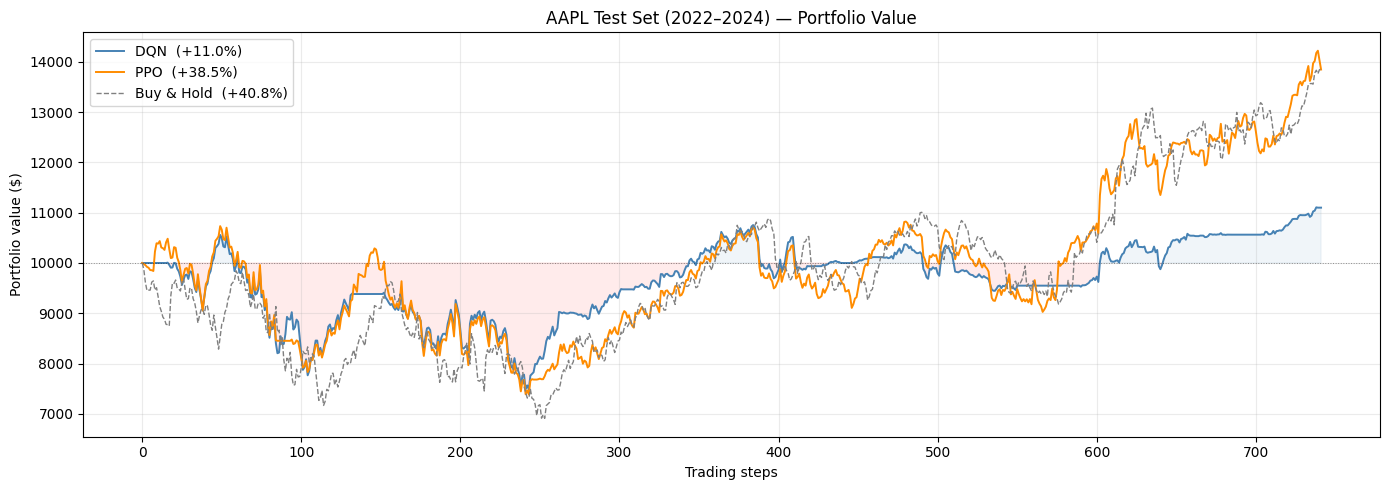

[PASS] Chart saved → reports/portfolio_comparison.png


In [13]:
dqn_port = pd.Series(dqn_env.portfolio_history)
ppo_port = pd.Series(ppo_env.portfolio_history)

# Buy & Hold series aligned to same length
prices   = test_raw['Close'].reset_index(drop=True)
bnh_port = 10_000 * (prices / prices.iloc[0])
bnh_port = bnh_port.iloc[:max(len(dqn_port), len(ppo_port))]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dqn_port.values, label=f'DQN  ({dqn_metrics["total_return"]:+.1f}%)',
        color='steelblue', linewidth=1.4)
ax.plot(ppo_port.values, label=f'PPO  ({ppo_metrics["total_return"]:+.1f}%)',
        color='darkorange', linewidth=1.4)
ax.plot(bnh_port.values[:len(dqn_port)],
        label=f'Buy & Hold  ({bnh_metrics["total_return"]:+.1f}%)',
        color='gray', linewidth=1, linestyle='--')
ax.axhline(10_000, color='black', linestyle=':', linewidth=0.7, alpha=0.4)
ax.fill_between(range(len(dqn_port)),
                [10_000]*len(dqn_port), dqn_port.values,
                where=(dqn_port.values >= 10_000),
                alpha=0.08, color='steelblue')
ax.fill_between(range(len(dqn_port)),
                [10_000]*len(dqn_port), dqn_port.values,
                where=(dqn_port.values < 10_000),
                alpha=0.08, color='red')
ax.set_title(f'{TICKER} Test Set (2022–2024) — Portfolio Value')
ax.set_ylabel('Portfolio value ($)')
ax.set_xlabel('Trading steps')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'portfolio_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[PASS] Chart saved → reports/portfolio_comparison.png')

---
## Cell 7 — Drawdown chart

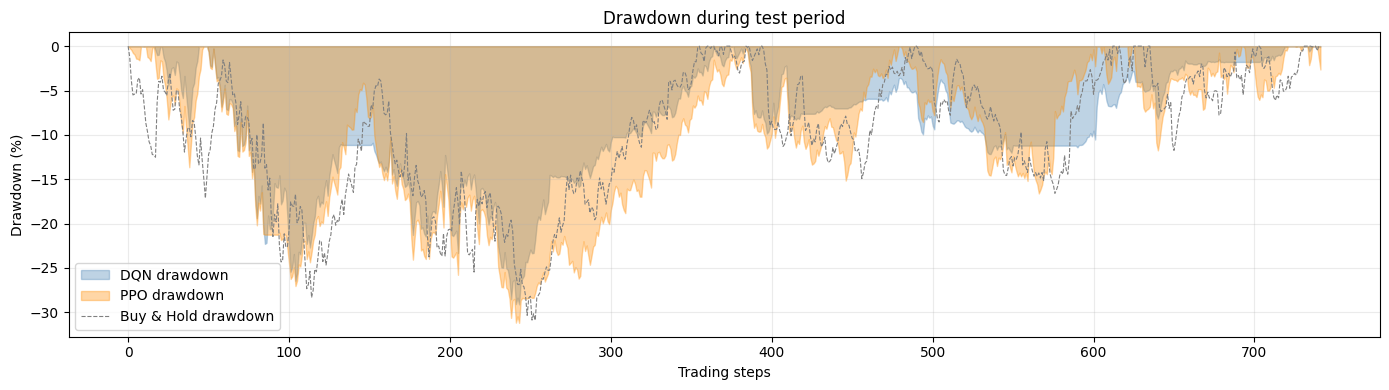

[PASS] Drawdown chart saved → reports/drawdown_chart.png


In [14]:
def drawdown_series(portfolio):
    s = pd.Series(portfolio)
    return ((s - s.cummax()) / s.cummax()) * 100

dqn_dd = drawdown_series(dqn_env.portfolio_history)
ppo_dd = drawdown_series(ppo_env.portfolio_history)
bnh_dd = drawdown_series(bnh_port.values[:len(dqn_dd)])

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(dqn_dd)), dqn_dd.values, 0,
                alpha=0.35, color='steelblue', label='DQN drawdown')
ax.fill_between(range(len(ppo_dd)), ppo_dd.values, 0,
                alpha=0.35, color='darkorange', label='PPO drawdown')
ax.plot(bnh_dd.values, color='gray', linewidth=0.8,
        linestyle='--', label='Buy & Hold drawdown')
ax.set_title('Drawdown during test period')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Trading steps')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'drawdown_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[PASS] Drawdown chart saved → reports/drawdown_chart.png')

---
## Cell 8 — Trade signals on price chart

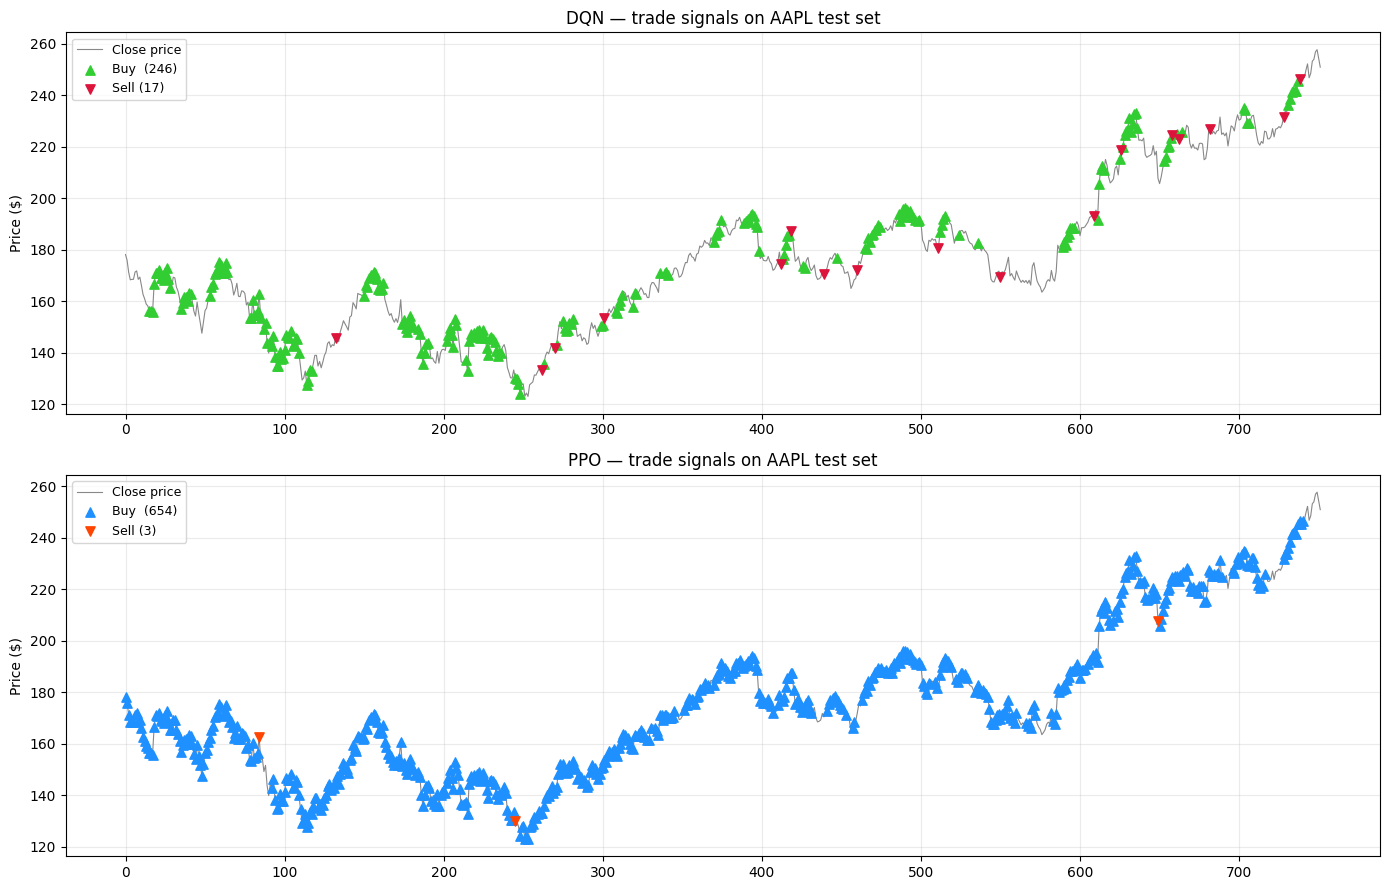

[PASS] Trade signal chart saved → reports/trade_signals.png


In [15]:
price_vals = test_raw['Close'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, env_obj, model_name, bc, sc in [
    (axes[0], dqn_env, 'DQN', 'limegreen', 'crimson'),
    (axes[1], ppo_env, 'PPO', 'dodgerblue', 'orangered'),
]:
    ax.plot(price_vals, color='#888', linewidth=0.8, label='Close price')
    tlog = env_obj.get_trade_log()
    if len(tlog) > 0:
        buys  = tlog[tlog['action'] == 'BUY']
        sells = tlog[tlog['action'] == 'SELL']
        bidx  = (buys['step'].values  - WINDOW_SIZE).clip(0, len(price_vals)-1)
        sidx  = (sells['step'].values - WINDOW_SIZE).clip(0, len(price_vals)-1)
        ax.scatter(bidx,  price_vals[bidx],  marker='^', color=bc, s=45,
                   zorder=5, label=f'Buy  ({len(buys)})')
        ax.scatter(sidx,  price_vals[sidx],  marker='v', color=sc, s=45,
                   zorder=5, label=f'Sell ({len(sells)})')
    ax.set_title(f'{model_name} — trade signals on {TICKER} test set')
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'trade_signals.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[PASS] Trade signal chart saved → reports/trade_signals.png')

---
## Cell 9 — Monthly returns heatmap

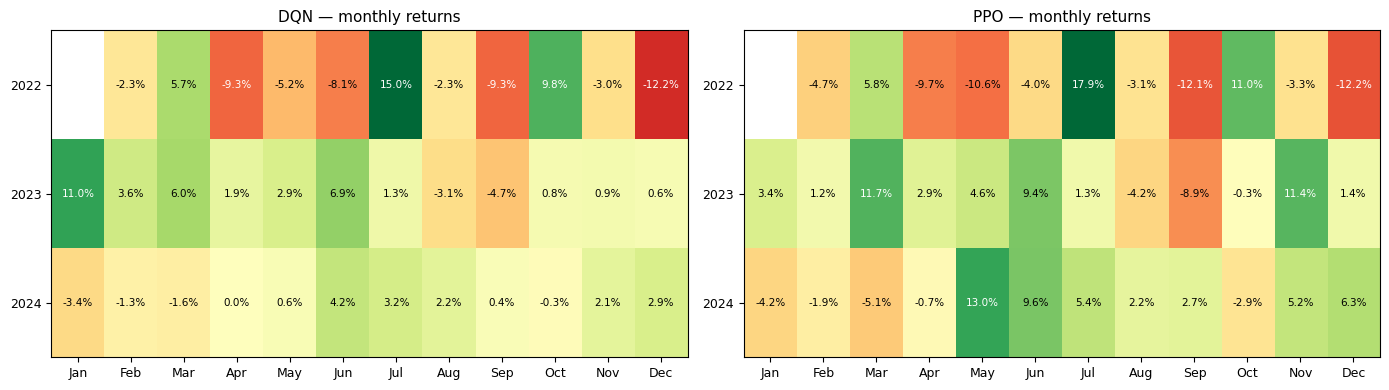

[PASS] Monthly returns heatmap saved → reports/monthly_returns.png


In [16]:
import calendar

def monthly_returns_heatmap(portfolio_history, date_index, title, ax):
    port  = pd.Series(
        portfolio_history,
        index = date_index[WINDOW_SIZE : WINDOW_SIZE + len(portfolio_history)]
    )
    rets  = port.resample('ME').last().pct_change().dropna() * 100
    pivot = pd.DataFrame({
        'year' : rets.index.year,
        'month': rets.index.month,
        'ret'  : rets.values
    }).pivot(index='year', columns='month', values='ret')
    pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

    import matplotlib.colors as mcolors
    cmap = plt.cm.RdYlGn
    vmax = pivot.abs().max().max()
    im   = ax.imshow(pivot.values, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=11)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                        fontsize=7.5,
                        color='black' if abs(v) < vmax*0.6 else 'white')
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly_returns_heatmap(dqn_env.portfolio_history, test_raw.index, 'DQN — monthly returns', axes[0])
monthly_returns_heatmap(ppo_env.portfolio_history, test_raw.index, 'PPO — monthly returns', axes[1])
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'monthly_returns.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[PASS] Monthly returns heatmap saved → reports/monthly_returns.png')

---
## Cell 10 — QuantStats HTML tearsheet

In [18]:
from backtest.backtester import generate_tearsheet
print('Generating QuantStats tearsheets...')
print('(Requires internet connection to fetch SPY benchmark data)')
print()

generate_tearsheet(
    dqn_env, test_raw,
    title       = f'DQN Trading Agent — {TICKER} 2022-2024',
    output_path = os.path.join(REPORT_DIR, 'dqn_tearsheet.html'),
)
generate_tearsheet(
    ppo_env, test_raw,
    title       = f'PPO Trading Agent — {TICKER} 2022-2024',
    output_path = os.path.join(REPORT_DIR, 'ppo_tearsheet.html'),
)

print()
print('Open reports/dqn_tearsheet.html in your browser for the full tearsheet.')
print('Screenshot the tearsheet summary for your GitHub README.')

Generating QuantStats tearsheets...
(Requires internet connection to fetch SPY benchmark data)

  Tearsheet saved → /Users/abdulmoiz/Downloads/RL Trading Agent/reports/dqn_tearsheet.html
  Tearsheet saved → /Users/abdulmoiz/Downloads/RL Trading Agent/reports/ppo_tearsheet.html

Open reports/dqn_tearsheet.html in your browser for the full tearsheet.
Screenshot the tearsheet summary for your GitHub README.


---
## Cell 11 — Trade log inspection

In [ ]:
for name, env_obj in [('DQN', dqn_env), ('PPO', ppo_env)]:
    tlog = env_obj.get_trade_log()
    print(f'{name} trade log:')
    print(f'  Total trades : {len(tlog)}')
    if len(tlog) > 0:
        buys  = tlog[tlog['action']=='BUY']
        sells = tlog[tlog['action']=='SELL']
        print(f'  Buys         : {len(buys)}')
        print(f'  Sells        : {len(sells)}')
        print(f'  Total cost   : ${tlog["cost"].sum():.2f}')
        print(f'  Avg buy px   : ${buys["price"].mean():.2f}'  if len(buys)  > 0 else '  Avg buy px : N/A')
        print(f'  Avg sell px  : ${sells["price"].mean():.2f}' if len(sells) > 0 else '  Avg sell px: N/A')
    print()

---
## Cell 12 — Files produced & Phase 5 summary

In [ ]:
print('='*55)
print('  Phase 5 — complete')
print('='*55)

files = [
    'reports/portfolio_comparison.png',
    'reports/drawdown_chart.png',
    'reports/trade_signals.png',
    'reports/monthly_returns.png',
    'reports/dqn_tearsheet.html',
    'reports/ppo_tearsheet.html',
]
for f in files:
    fpath  = os.path.join(PROJECT_ROOT, f)
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath)/1024 if exists else 0
    status = '[PASS]' if exists else '[MISS]'
    print(f'  {status}  {f:<45} {size:.0f} KB')

print()
print('  Final metrics (test set):')
print(f"  DQN  return={dqn_metrics['total_return']:+.2f}%  sharpe={dqn_metrics['sharpe']:.3f}  dd={dqn_metrics['max_drawdown']:.2f}%")
print(f"  PPO  return={ppo_metrics['total_return']:+.2f}%  sharpe={ppo_metrics['sharpe']:.3f}  dd={ppo_metrics['max_drawdown']:.2f}%")
print(f"  B&H  return={bnh_metrics['total_return']:+.2f}%  sharpe={bnh_metrics['sharpe']:.3f}  dd={bnh_metrics['max_drawdown']:.2f}%")
print()
print('  Next: Phase 6 — Streamlit dashboard')
print('='*55)